In [15]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [16]:
df_cleaned = pd.read_csv('insurance_cleaned.csv')

In [17]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0,0,0,1
1,18,0,33.770,1,0,1725.55230,0,0,1,0
2,28,0,33.000,3,0,4449.46200,0,0,1,0
3,33,0,22.705,0,0,21984.47061,0,1,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0


<Axes: xlabel='bmi', ylabel='Count'>

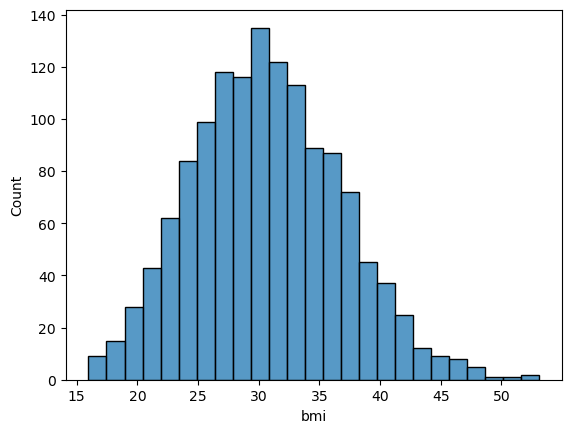

In [25]:
sns.histplot(df_cleaned['bmi'])

In [19]:
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'],
    bins=[0, 18.5, 24.9, 29.9, float('inf')],
    labels=['underweight', 'normal', 'overweight', 'obese']
)

In [20]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27.900,0,1,16884.92400,0,0,0,1,overweight
1,18,0,33.770,1,0,1725.55230,0,0,1,0,obese
2,28,0,33.000,3,0,4449.46200,0,0,1,0,obese
3,33,0,22.705,0,0,21984.47061,0,1,0,0,normal
4,32,0,28.880,0,0,3866.85520,0,1,0,0,overweight
...,...,...,...,...,...,...,...,...,...,...,...
1332,50,0,30.970,3,0,10600.54830,0,1,0,0,obese
1333,18,1,31.920,0,0,2205.98080,1,0,0,0,obese
1334,18,1,36.850,0,0,1629.83350,0,0,1,0,obese
1335,21,1,25.800,0,0,2007.94500,0,0,0,1,overweight


In [21]:
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'],
    bins=[0, 18.5, 24.9, 29.9, float('inf')],
    labels=['underweight', 'normal', 'overweight', 'obese']
)

In [22]:
df_cleaned[['bmi', 'bmi_category']].head()

,bmi,bmi_category
0,27.900,overweight
1,33.770,obese
2,33.000,obese
3,22.705,normal
4,28.880,overweight


In [23]:
df_cleaned = pd.get_dummies(
    df_cleaned,
    columns=['bmi_category'],
    drop_first=True,
    dtype=int
)

In [24]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,1,27.900,0,1,16884.92400,0,0,0,1,0,1,0
1,18,0,33.770,1,0,1725.55230,0,0,1,0,0,0,1
2,28,0,33.000,3,0,4449.46200,0,0,1,0,0,0,1
3,33,0,22.705,0,0,21984.47061,0,1,0,0,1,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0,0,1,0


In [26]:
df_cleaned.astype(int)

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,1,27,0,1,16884,0,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,0,1,0,0,0,1
3,33,0,22,0,0,21984,0,1,0,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1332,50,0,30,3,0,10600,0,1,0,0,0,0,1
1333,18,1,31,0,0,2205,1,0,0,0,0,0,1
1334,18,1,36,0,0,1629,0,0,1,0,0,0,1
1335,21,1,25,0,0,2007,0,0,0,1,0,1,0


In [27]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,1,27.900,0,1,16884.92400,0,0,0,1,0,1,0
1,18,0,33.770,1,0,1725.55230,0,0,1,0,0,0,1
2,28,0,33.000,3,0,4449.46200,0,0,1,0,0,0,1
3,33,0,22.705,0,0,21984.47061,0,1,0,0,1,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0,0,1,0


In [28]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_normal', 'bmi_category_overweight',
       'bmi_category_obese'],
      dtype='object')

In [31]:
from sklearn.preprocessing import StandardScaler

In [32]:
cols=['age','bmi','children']
scaler=StandardScaler()

df_cleaned[cols]=scaler.fit_transform(df_cleaned[cols])

In [33]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,-1.440418,1,-0.453160,-0.909234,1,16884.92400,0,0,0,1,0,1,0
1,-1.511647,0,0.509422,-0.079442,0,1725.55230,0,0,1,0,0,0,1
2,-0.799350,0,0.383155,1.580143,0,4449.46200,0,0,1,0,0,0,1
3,-0.443201,0,-1.305052,-0.909234,0,21984.47061,0,1,0,0,1,0,0
4,-0.514431,0,-0.292456,-0.909234,0,3866.85520,0,1,0,0,0,1,0


In [34]:
from scipy.stats import pearsonr

In [35]:
selected_features = [
    'age',
    'bmi',
    'children',
    'is_female',
    'is_smoker',
    'region_northwest',
    'region_southeast',
    'region_southwest',
    'bmi_category_normal',
    'bmi_category_overweight',
    'bmi_category_obese'
]

In [37]:
from scipy.stats import pearsonr

correlations = {
    feature: pearsonr(
        df_cleaned[feature],
        df_cleaned['charges']
    )[0]
    for feature in selected_features
}

correlations = dict(
    sorted(
        correlations.items(),
        key=lambda x: abs(x[1]),
        reverse=True
    )
)

correlations

{'is_smoker': np.float64(0.7872343672800316),
 'age': np.float64(0.29830821250978634),
 'bmi': np.float64(0.19840083122624938),
 'bmi_category_obese': np.float64(0.19765936538425974),
 'bmi_category_overweight': np.float64(-0.118279404344456),
 'bmi_category_normal': np.float64(-0.1056549118470303),
 'region_southeast': np.float64(0.07357792870627781),
 'children': np.float64(0.06738935083963252),
 'is_female': np.float64(-0.05804449579031286),
 'region_southwest': np.float64(-0.04363736849776149),
 'region_northwest': np.float64(-0.03869463262101644)}

In [38]:
correlation_table = pd.DataFrame(
    correlations.items(),
    columns=['Feature', 'Pearson_Correlation']
)

correlation_table

,Feature,Pearson_Correlation
0,is_smoker,0.787234
1,age,0.298308
2,bmi,0.198401
3,bmi_category_obese,0.197659
4,bmi_category_overweight,-0.118279
5,bmi_category_normal,-0.105655
6,region_southeast,0.073578
7,children,0.067389
8,is_female,-0.058044
9,region_southwest,-0.043637


In [40]:
from sklearn.feature_selection import mutual_info_regression
import pandas as pd

X = df_cleaned.drop('charges', axis=1)
y = df_cleaned['charges']

mi_scores = mutual_info_regression(
    X,
    y,
    random_state=42
)

mi_scores = pd.Series(
    mi_scores,
    index=X.columns
).sort_values(ascending=False)

print(mi_scores)

age                        1.497960
is_smoker                  0.369276
is_female                  0.176281
children                   0.161101
bmi_category_obese         0.085795
bmi                        0.072145
region_northwest           0.056791
region_northeast           0.054331
bmi_category_overweight    0.040394
region_southeast           0.035002
bmi_category_normal        0.032223
region_southwest           0.002465
dtype: float64


In [41]:
df_cleaned.drop(
    columns=[
        'region_southwest',
        'region_southeast',
        'region_northeast',
        'region_northwest'
    ],
    inplace=True
)

In [42]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,-1.440418,1,-0.453160,-0.909234,1,16884.92400,0,1,0
1,-1.511647,0,0.509422,-0.079442,0,1725.55230,0,0,1
2,-0.799350,0,0.383155,1.580143,0,4449.46200,0,0,1
3,-0.443201,0,-1.305052,-0.909234,0,21984.47061,1,0,0
4,-0.514431,0,-0.292456,-0.909234,0,3866.85520,0,1,0
